# 01 · Schema Overview

**Week 1 Goal**: load every raw dataset, print shape / dtypes / null counts / sample rows, and capture findings into `docs/data_dictionary.md`.

Do **not** commit notebook outputs (handled by `nbstripout` in pre-commit, or strip manually before commit).

In [ ]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import pandas as pd

# Visualize grant size distributions
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

# Resolve repo root
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'data' / 'processed').exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
PROCESSED_DIR = REPO_ROOT / 'data' / 'processed'
assert PROCESSED_DIR.exists(), f'data/processed folder not found from {Path.cwd()}'
print('Repo root:', REPO_ROOT)
print('Processed data dir:', PROCESSED_DIR)
print('Available parquet files:', sorted(p.name for p in PROCESSED_DIR.glob('*.parquet')))

Repo root: /Users/uttkarshnarayan/projects/northeastern_visualization
Processed data dir: /Users/uttkarshnarayan/projects/northeastern_visualization/data/processed
Available parquet files: ['faculty.parquet', 'faculty_id_lookup.parquet', 'grant_faculty.parquet', 'grant_text.parquet', 'grant_topics.parquet', 'grants.parquet']


In [43]:
# Load cleaned, normalized Parquet tables from Week 3 pipeline
faculty = pd.read_parquet(PROCESSED_DIR / 'faculty.parquet')
grants = pd.read_parquet(PROCESSED_DIR / 'grants.parquet')
grant_faculty = pd.read_parquet(PROCESSED_DIR / 'grant_faculty.parquet')
grant_text = pd.read_parquet(PROCESSED_DIR / 'grant_text.parquet')
faculty_lookup = pd.read_parquet(PROCESSED_DIR / 'faculty_id_lookup.parquet')

# Create a 'ri' dataframe by merging grants + grant_faculty for compatibility with existing analysis code
ri = grant_faculty.merge(grants, on='grantid', how='left')

print("Loaded tables:")
print(f"  faculty:         {faculty.shape}")
print(f"  grants:          {grants.shape}")
print(f"  grant_faculty:   {grant_faculty.shape}")
print(f"  grant_text:      {grant_text.shape}")
print(f"  faculty_lookup:  {faculty_lookup.shape}")
print(f"  ri (merged):     {ri.shape} — compatible with existing analysis\n")
print("Data is clean, normalized, and ready for analysis.")
print("\nColumn names in ri:")
print(list(ri.columns))

Loaded tables:
  faculty:         (2247, 7)
  grants:          (2676, 11)
  grant_faculty:   (3146, 5)
  grant_text:      (8075, 5)
  faculty_lookup:  (570, 2)
  ri (merged):     (3146, 15) — compatible with existing analysis

Data is clean, normalized, and ready for analysis.

Column names in ri:
['grantid', 'clientfacultyid', 'personname', 'iscopi', 'aauid', 'grantname', 'agencycode', 'agencyname', 'totaldollars', 'startdate', 'enddate', 'durationinyears', 'countrycode', 'isgovernment', 'startdateyear']


## Data Processing Note

**This notebook now loads cleaned, normalized Parquet data** from the Week 3 pipeline (`src/build_dataset.py`).

All raw xlsx files have been:
- Cleaned (100% null columns dropped, trailing spaces removed)
- Normalized (categorical values standardized, dtypes coerced)
- Deduplicated (grant-level rows are unique; faculty rows are unique)
- Validated (join keys confirmed, date ranges checked)

The `ri` dataframe is a merged version of `grant_faculty` + `grants` for backward compatibility with existing analysis code.

**To update data:** Run `python src/build_dataset.py` after any data refresh; all notebooks will automatically pick up cleaned tables.

In [44]:
# Helper function for exploratory data profiling (optional, not used in current analysis)
def profile(df: pd.DataFrame, label: str) -> None:
    """Print comprehensive data profile for a DataFrame."""
    print('=' * 80)
    print(f'{label}  —  shape={df.shape}')
    print('=' * 80)
    print('\n--- dtypes ---')
    print(df.dtypes.to_string())
    print('\n--- null counts (non-zero only) ---')
    nulls = df.isna().sum()
    print(nulls[nulls > 0].sort_values(ascending=False).to_string() or '(none)')
    print('\n--- head(5) ---')
    display(df.head(5))
    print('\n--- describe(include="all") ---')
    display(df.describe(include='all').T)

## Top 10 faculty earners by total grant dollars

Source: `ri_matches_grants_2026` (canonical structured grants table). Each grant is split across faculty rows; to avoid double-counting a multi-PI grant, we deduplicate to one `(grantid, AAUID)` row and then sum `totaldollars` per faculty member. Co-PIs share full credit for the grant they were attached to.


## Schema of Cleaned Tables

**faculty:** College/department roster with normalized ranks  
**grants:** Deduplicated grant-level data (one row per grantid)  
**grant_faculty:** Long-form grant × faculty relationships (PI/co-PI flags)  
**ri:** Merged view of grant_faculty + grants (backward-compatible for analysis)



In [45]:
# Data is already loaded from Parquet in cell 3 as 'ri'
# Top 10 faculty earners by total grant dollars

# Deduplicate on grant + faculty combination
ri_dedup = ri[['grantid', 'clientfacultyid', 'personname', 'totaldollars', 'iscopi', 'startdateyear']].drop_duplicates(subset=['grantid', 'clientfacultyid'])

# Aggregate by faculty
top10 = (
    ri_dedup.groupby(['clientfacultyid', 'personname'], as_index=False)
    .agg(
        total_dollars=('totaldollars', 'sum'),
        n_grants=('grantid', 'nunique'),
        n_as_copi=('iscopi', 'sum'),
        first_year=('startdateyear', 'min'),
        last_year=('startdateyear', 'max')
    )
    .sort_values('total_dollars', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top10['total_dollars'] = top10['total_dollars'].map(lambda v: f'${v:,.0f}')
top10

,clientfacultyid,personname,total_dollars,n_grants,n_as_copi,first_year,last_year
0,1793665,"MELODIA, TOMMASO","$91,387,201",40,13,2010,2025
1,141504,"ALSHAWABKEH, AKRAM N","$87,619,945",19,5,2001,2020
2,148962,"MAKRIYANNIS, ALEXANDROS","$61,984,392",25,2,2004,2022
3,1383874,"LEVINE, HERBERT","$47,122,908",36,7,2001,2025
4,148351,"LEWIS, KIM","$46,153,290",21,1,2004,2022
5,2474499,"QUARANTA, VITO","$45,827,727",14,1,2004,2018
6,2108075,"WINSLOW, RAI LESTER","$40,300,548",21,3,2005,2020
7,951814,"ABUR, ALI","$38,745,428",8,1,2005,2024
8,148296,"KAELI, DAVID R","$33,796,673",33,15,1995,2024
9,2980311,"BRONICH, TATIANA KARPOVNA","$33,482,077",12,2,2005,2018


## Faculty Distribution

In [46]:
# Faculty data already loaded from Parquet in cell 3 as 'faculty'
# Group by college

by_college = (
    faculty.groupby('superior_academic_unit', as_index=False)
    .agg(n_faculty=('employee id', 'nunique'))
    .sort_values('n_faculty', ascending=False)
    .reset_index(drop=True)
)

total = by_college['n_faculty'].sum()
by_college['pct_of_total'] = (by_college['n_faculty'] / total * 100).apply(lambda x: f'{x:.1f}%')

print(f'Total faculty: {total:,}  across {len(by_college)} colleges')
by_college

Total faculty: 2,232  across 12 colleges


/var/folders/bs/ccwn6prd5ld07zw45ch_gsc00000gn/T/ipykernel_46584/4076630721.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  faculty.groupby('superior_academic_unit', as_index=False)


,superior_academic_unit,n_faculty,pct_of_total
0,College of Engineering,356,15.9%
1,College of Science,332,14.9%
2,College of Social Sciences and Humanities,304,13.6%
3,Bouvé College of Health Sciences,269,12.1%
4,D'Amore-McKim School of Business,215,9.6%
5,"College of Arts, Media and Design",210,9.4%
6,Khoury College of Computer Sciences,210,9.4%
7,Northeastern University London,126,5.6%
8,College of Professional Studies,110,4.9%
9,School of Law,58,2.6%


In [47]:
# Academic Rank distribution (using already-loaded faculty data)
by_rank = (
    faculty.groupby('academic rank', as_index=False)
    .agg(n_faculty=('employee id', 'nunique'))
    .sort_values('n_faculty', ascending=False)
    .reset_index(drop=True)
)

total = by_rank['n_faculty'].sum()
by_rank['pct_of_total'] = (by_rank['n_faculty'] / total * 100).apply(lambda x: f'{x:.1f}%')

print(f'Total faculty: {total:,}  across {len(by_rank)} ranks')
by_rank

Total faculty: 2,232  across 10 ranks


/var/folders/bs/ccwn6prd5ld07zw45ch_gsc00000gn/T/ipykernel_46584/2278726703.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  faculty.groupby('academic rank', as_index=False)


,academic rank,n_faculty,pct_of_total
0,Professor,534,23.9%
1,Assistant Professor,387,17.3%
2,Associate Professor,355,15.9%
3,Associate Teaching Professor,251,11.2%
4,Assistant Teaching Professor,233,10.4%
5,Teaching Professor,188,8.4%
6,Other,152,6.8%
7,Research Professor,50,2.2%
8,Visiting / Adjunct,47,2.1%
9,Lecturer,35,1.6%


In [48]:
# College Breakdown (by Superior Academic Unit and Track Type)
# Pivot: Academic Unit × Academic Track Type
pivot_unit = faculty.pivot_table(
    index='superior_academic_unit',
    columns='academic track type',
    values='employee id',
    aggfunc='nunique',
    fill_value=0,
)
pivot_unit['TOTAL'] = pivot_unit.sum(axis=1)
pivot_unit = pivot_unit.sort_values('TOTAL', ascending=False)
pivot_unit.index.name = 'academic unit'
pivot_unit.columns.name = None

# Same column ordering: tenure-related first, then others, then TOTAL
cols = [c for c in pivot_unit.columns if c != 'TOTAL']
tenure_cols = sorted([c for c in cols if 'tenure' in str(c).lower()])
other_cols  = sorted([c for c in cols if 'tenure' not in str(c).lower()])
pivot_unit = pivot_unit[tenure_cols + other_cols + ['TOTAL']]

print(f'{len(pivot_unit)} academic units\n')
pivot_unit

12 academic units



/var/folders/bs/ccwn6prd5ld07zw45ch_gsc00000gn/T/ipykernel_46584/4209158770.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_unit = faculty.pivot_table(


,Non-Tenure,Tenure Track,Research Only,Teaching Only,Teaching and Research,Teaching and Scholarship,Visiting Lecturers,TOTAL
academic unit,,,,,,,,
College of Engineering,149,207,0,0,0,0,0,356
College of Science,143,172,0,2,2,8,5,332
College of Social Sciences and Humanities,122,152,0,0,0,4,26,304
Bouvé College of Health Sciences,174,87,0,0,0,0,8,269
D'Amore-McKim School of Business,122,93,0,0,0,0,0,215
"College of Arts, Media and Design",100,103,0,0,0,0,7,210
Khoury College of Computer Sciences,129,80,0,0,0,0,1,210
Northeastern University London,0,0,4,8,45,69,0,126
College of Professional Studies,106,1,0,0,0,0,3,110


In [49]:
# Pivot: Academic Unit × Academic Track Type
pivot_unit = faculty.pivot_table(
    index='academic unit',
    columns='academic track type',
    values='employee id',
    aggfunc='nunique',
    fill_value=0,
)
pivot_unit['TOTAL'] = pivot_unit.sum(axis=1)
pivot_unit = pivot_unit.sort_values('TOTAL', ascending=False)
pivot_unit.index.name = 'academic unit'
pivot_unit.columns.name = None

# Same column ordering: tenure-related first, then others, then TOTAL
cols = [c for c in pivot_unit.columns if c != 'TOTAL']
tenure_cols = sorted([c for c in cols if 'tenure' in str(c).lower()])
other_cols  = sorted([c for c in cols if 'tenure' not in str(c).lower()])
pivot_unit = pivot_unit[tenure_cols + other_cols + ['TOTAL']]

print(f'{len(pivot_unit)} academic units\n')
with pd.option_context('display.max_rows', None):
    display(pivot_unit)


80 academic units



/var/folders/bs/ccwn6prd5ld07zw45ch_gsc00000gn/T/ipykernel_46584/3408379703.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_unit = faculty.pivot_table(


,Non-Tenure,Tenure Track,Research Only,Teaching Only,Teaching and Research,Teaching and Scholarship,Visiting Lecturers,TOTAL
academic unit,,,,,,,,
Khoury College of Computer Sciences,129,80,0,0,0,0,1,210
College of Professional Studies,106,1,0,0,0,0,3,110
Electrical and Computer Engineering,23,75,0,0,0,0,0,98
College of Engineering,82,0,0,0,0,0,0,82
Mechanical and Industrial Engineering,25,56,0,0,0,0,0,81
Art and Design,40,38,0,0,0,0,1,79
Physics,17,49,0,0,0,0,0,66
English,33,20,0,0,0,0,12,65
School of Law,22,33,0,0,0,0,3,58


Matched faculty  : 557 of 2,247 (24.8% of roster)
Total grant-rows : 3,072

College-level grant summary:


,n_faculty_total,n_with_grants,pct_with_grants,n_grants,total_dollars,avg_grants_per_person,avg_dollars_per_person,total_copi
superior_academic_unit,,,,,,,,
College of Engineering,356,172,48.3,1148,955332019,6.674419,5554256.0,294
College of Science,332,142,42.8,868,683530322,6.112676,4813594.0,185
Khoury College of Computer Sciences,210,68,32.4,420,329848931,6.176471,4850720.0,109
Bouvé College of Health Sciences,269,66,24.5,292,391758688,4.424242,5935738.0,38
College of Social Sciences and Humanities,304,50,16.4,142,91106859,2.840000,1822137.0,45
"College of Arts, Media and Design",210,24,11.4,61,40331454,2.541667,1680477.0,29
School of Law,58,7,12.1,12,9317837,1.714286,1331120.0,4
D'Amore-McKim School of Business,215,9,4.2,11,4600125,1.222222,511125.0,3
Northeastern University,2,1,50.0,6,1190045,6.000000,1190045.0,2


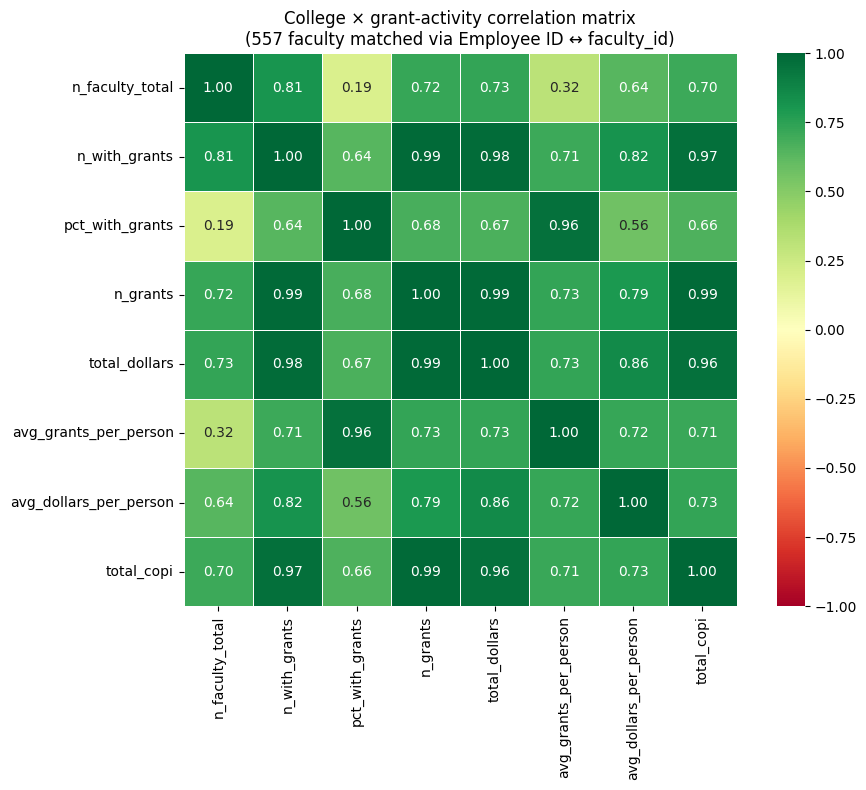

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

# Data already loaded from Parquet in cell 3
# ── Join: Employee ID ↔ faculty_id ──────────────────────────────────────
ri_dedup = ri.drop_duplicates(subset=['grantid', 'clientfacultyid'])

per_person = (
    ri_dedup.groupby('clientfacultyid', as_index=False, observed=True)
            .agg(
                n_grants           = ('grantid',      'nunique'),
                total_dollars      = ('totaldollars',  'sum'),
                n_copi             = ('iscopi',        'sum'),
                n_agencies         = ('agencyname',   'nunique'),
                year_span          = ('startdateyear', lambda x: int(x.max() - x.min() + 1) if x.notna().any() else 0),
            )
)

merged = faculty.merge(
    per_person,
    left_on='employee id',
    right_on='clientfacultyid',
    how='inner',
)

n_matched  = merged['employee id'].nunique()
n_total    = faculty['employee id'].nunique()
n_grants   = merged['n_grants'].sum()
print(f"Matched faculty  : {n_matched:,} of {n_total:,} ({n_matched/n_total*100:.1f}% of roster)")
print(f"Total grant-rows : {int(n_grants):,}\n")

# ── College-level grant summary ───────────────────────────────────────────────
faculty_counts = (
    faculty.groupby('superior_academic_unit', observed=True)['employee id']
           .nunique()
           .rename('n_faculty_total')
)

college_stats = (
    merged.groupby('superior_academic_unit', observed=True)
          .agg(
              n_with_grants         = ('employee id',   'nunique'),
              n_grants              = ('n_grants',      'sum'),
              total_dollars         = ('total_dollars', 'sum'),
              avg_grants_per_person = ('n_grants',      'mean'),
              total_copi            = ('n_copi',        'sum'),
          )
          .join(faculty_counts)
)
college_stats['pct_with_grants'] = (
    college_stats['n_with_grants'] / college_stats['n_faculty_total'] * 100
).round(1)
college_stats['avg_dollars_per_person'] = (
    college_stats['total_dollars'] / college_stats['n_with_grants']
).round(0)
college_stats = college_stats.sort_values('n_grants', ascending=False)

print("College-level grant summary:")
display(college_stats[[
    'n_faculty_total', 'n_with_grants', 'pct_with_grants',
    'n_grants', 'total_dollars', 'avg_grants_per_person',
    'avg_dollars_per_person', 'total_copi',
]])

# ── Correlation matrix ────────────────────────────────────────────────────────
corr_cols = [
    'n_faculty_total', 'n_with_grants', 'pct_with_grants',
    'n_grants', 'total_dollars', 'avg_grants_per_person',
    'avg_dollars_per_person', 'total_copi',
]
corr = college_stats[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=-1, vmax=1, center=0,
    linewidths=0.5, square=True, ax=ax,
)
ax.set_title(
    f'College × grant-activity correlation matrix\n'
    f'({n_matched:,} faculty matched via Employee ID ↔ faculty_id)',
    fontsize=12,
)
plt.tight_layout()
plt.show()

Total PI ↔ co-PI pairs across all grants: 437
Unique grants with ≥1 co-PI            : 291

After mapping:
  PI missing college   : 19 of 159 unique PIs
  co-PI missing college: 29 of 212 unique co-PIs

Top 20 PI ↔ co-PI collaboration pairs (with grant details):


,pi_name,pi_college,copi_name,copi_college,n_grants,grant_titles (unique grants seperated by |),agencies
0,"ONDRECHEN, MARY JO",College of Science,"BEUNING, PENNY J",College of Science,7,Are Enzyme Active Sites Built in Multiple Layers? | Chem...,National Science Foundation
1,"WOOD, DARIEN",College of Science,"BARBERIS, EMANUELA",College of Science,6,Experimental High Energy Particle Physics | Experimental...,National Science Foundation
2,"ZEID, IBRAHIM",College of Engineering,"DUGGAN, CLAIRE",(still unmatched),5,BPE-Track 2: Modernizing Education: Using AI to Improve ...,National Science Foundation
3,"NATH, PRAN",College of Science,"TAYLOR, TOMASZ R",College of Science,5,Research in Elementary Particle Theory | Research in Ele...,National Science Foundation
4,"SZNAIER, MARIO",College of Engineering,"CAMPS, OCTAVIA",College of Engineering,5,CPS:Medium: Safe Learning-Enabled Cyberphysical Systems ...,National Science Foundation
...,...,...,...,...,...,...,...
341,"KAMARTHI, SAGAR V",College of Engineering,"ISAACS, JACKIE A",(still unmatched),1,Developing Integrative Manufacturing and Production Engi...,National Science Foundation
342,"KAELI, DAVID R",College of Engineering,"WANG, YANZHI",College of Engineering,1,MRI: Acquisition of a Heterogeneous Multi-GPU Cluster to...,National Science Foundation
343,"KAELI, DAVID R",College of Engineering,"TIWARI, DEVESH",(still unmatched),1,MRI: Acquisition of a Heterogeneous Multi-GPU Cluster to...,National Science Foundation
344,"KAELI, DAVID R",College of Engineering,"LIN, XUE",College of Engineering,1,MRI: Acquisition of a Heterogeneous Multi-GPU Cluster to...,National Science Foundation



Pairs with both sides matched to a college: 392 of 437 (89.7%)



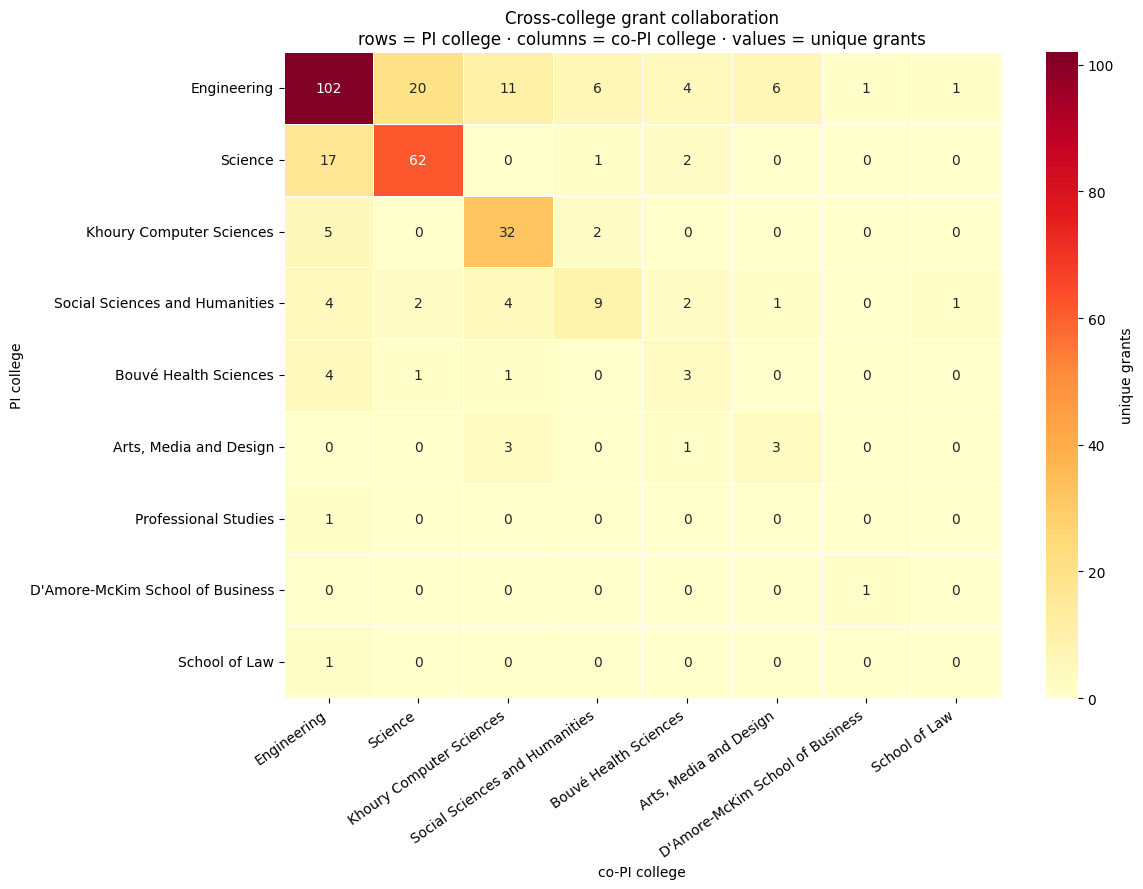

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

# Data already loaded from Parquet in cell 3
ri_dedup = ri.drop_duplicates(subset=['grantid', 'clientfacultyid'])

# ── 1. Build PI ↔ co-PI pairs per grant ──────────────────────────────────────
pi_rows   = ri_dedup[ri_dedup['iscopi'] == 0][['grantid', 'clientfacultyid', 'personname']].rename(
    columns={'clientfacultyid': 'pi_id', 'personname': 'pi_name'})
copi_rows = ri_dedup[ri_dedup['iscopi'] == 1][['grantid', 'clientfacultyid', 'personname']].rename(
    columns={'clientfacultyid': 'copi_id', 'personname': 'copi_name'})

pairs = pi_rows.merge(copi_rows, on='grantid')
print(f"Total PI ↔ co-PI pairs across all grants: {len(pairs):,}")
print(f"Unique grants with ≥1 co-PI            : {pairs['grantid'].nunique():,}\n")

# ── 1b. Add grant details (title and funding source) ─────────────────────────
grant_details = ri_dedup[['grantid', 'grantname', 'agencyname']].drop_duplicates(subset=['grantid'])
pairs = pairs.merge(grant_details, on='grantid', how='left')

# ── 2. Enrich each person with college via Employee ID ↔ clientfacultyid ──────
id_to_college = (
    faculty.dropna(subset=['employee id'])
           .set_index('employee id')['superior_academic_unit']
           .to_dict()
)

pairs['pi_college']   = pairs['pi_id'].map(id_to_college)
pairs['copi_college'] = pairs['copi_id'].map(id_to_college)

# ── 2b. Use faculty_lookup for additional unmatched faculty mapping ──
id_to_college_lookup = faculty_lookup.set_index('faculty_id')['college'].to_dict()
pairs['pi_college']   = pairs['pi_college'].fillna(pairs['pi_id'].map(id_to_college_lookup))
pairs['copi_college'] = pairs['copi_college'].fillna(pairs['copi_id'].map(id_to_college_lookup))

print(f"After mapping:")
print(f"  PI missing college   : {pairs['pi_college'].isna().sum()} of {len(pairs.drop_duplicates('pi_id'))} unique PIs")
print(f"  co-PI missing college: {pairs['copi_college'].isna().sum()} of {len(pairs.drop_duplicates('copi_id'))} unique co-PIs\n")

# ── 3. All collaboration pairs (with colleges, grant titles, and agencies) ────
all_pairs = (
    pairs.groupby(['pi_name', 'pi_college', 'copi_name', 'copi_college'], as_index=False, dropna=False)
         .agg(
             n_grants=('grantid', 'nunique'),
             **{'grant_titles (unique grants seperated by |)': ('grantname', lambda x: ' | '.join(sorted(set(x.dropna()))[:5]) )},  # Top 5 unique titles
             agencies=('agencyname', lambda x: ', '.join(sorted(set(x.dropna()))))
         )
         .sort_values('n_grants', ascending=False)
         .reset_index(drop=True)
)
all_pairs['pi_college']   = all_pairs['pi_college'].fillna('(still unmatched)')
all_pairs['copi_college'] = all_pairs['copi_college'].fillna('(still unmatched)')
print("Top 20 PI ↔ co-PI collaboration pairs (with grant details):")
with pd.option_context('display.max_rows', 20, 'display.max_colwidth', 60):
    display(all_pairs[['pi_name', 'pi_college', 'copi_name', 'copi_college', 'n_grants', 'grant_titles (unique grants seperated by |)', 'agencies']])

# ── 4. College × college collaboration matrix ─────────────────────────────────
matched = pairs.dropna(subset=['pi_college', 'copi_college'])
n_pairs_matched = len(matched)
n_pairs_total   = len(pairs)
print(f"\nPairs with both sides matched to a college: {n_pairs_matched:,} of {n_pairs_total:,} "
      f"({n_pairs_matched/n_pairs_total*100:.1f}%)\n")

collab_matrix = (
    matched.groupby(['pi_college', 'copi_college'])['grantid']
           .nunique()
           .unstack(fill_value=0)
)

row_order = collab_matrix.sum(axis=1).sort_values(ascending=False).index
col_order = collab_matrix.sum(axis=0).sort_values(ascending=False).index
collab_matrix = collab_matrix.loc[row_order, col_order]

short = lambda s: s.replace('College of ', '').replace('Northeastern University ', 'NU ')
collab_matrix.index   = [short(c) for c in collab_matrix.index]
collab_matrix.columns = [short(c) for c in collab_matrix.columns]

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    collab_matrix, annot=True, fmt='d', cmap='YlOrRd',
    linewidths=0.4, ax=ax, cbar_kws={'label': 'unique grants'}
)
ax.set_title(
    'Cross-college grant collaboration\n'
    'rows = PI college · columns = co-PI college · values = unique grants',
    fontsize=12,
)
ax.set_xlabel('co-PI college')
ax.set_ylabel('PI college')
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [52]:
# Summary: Unmatched individuals (from collaboration analysis)
# Note: The 'pairs' dataframe was created in the cell above with colleges filled in

# Unique PIs still missing college
unmatched_pis = pairs[pairs['pi_college'].isna()][['pi_id', 'pi_name']].drop_duplicates()
n_unmatched_pi = len(unmatched_pis)

# Unique co-PIs still missing college
unmatched_copis = pairs[pairs['copi_college'].isna()][['copi_id', 'copi_name']].drop_duplicates()
n_unmatched_copi = len(unmatched_copis)

# Total unique faculty in pairs
total_unique_pis = pairs[['pi_id', 'pi_name']].drop_duplicates()
total_unique_copis = pairs[['copi_id', 'copi_name']].drop_duplicates()

print(f"Still unmatched after pipeline mapping:")
print(f"  PIs   : {n_unmatched_pi:,} of {len(total_unique_pis):,} "
      f"({n_unmatched_pi/len(total_unique_pis)*100:.1f}%)")
print(f"  co-PIs: {n_unmatched_copi:,} of {len(total_unique_copis):,} "
      f"({n_unmatched_copi/len(total_unique_copis)*100:.1f}%)")

if n_unmatched_pi > 0 or n_unmatched_copi > 0:
    # Combined unique individuals still unmatched
    all_still_unmatched = pd.concat([
        unmatched_pis.rename(columns={'pi_id': 'id', 'pi_name': 'name'}),
        unmatched_copis.rename(columns={'copi_id': 'id', 'copi_name': 'name'})
    ]).drop_duplicates(subset=['id']).sort_values('name').reset_index(drop=True)
    
    print(f"\nIndividuals still missing college mapping: {len(all_still_unmatched):,}")
    print("\nList of still-unmatched individuals:")
    with pd.option_context('display.max_rows', None):
        display(all_still_unmatched)
else:
    print("\n✓ All individuals successfully mapped to colleges!")

Still unmatched after pipeline mapping:
  PIs   : 8 of 159 (5.0%)
  co-PIs: 11 of 212 (5.2%)

Individuals still missing college mapping: 15

List of still-unmatched individuals:


,id,name
0,2628747,"ANDERSON, ERIC WILLIAM"
1,141388,"DUGGAN, CLAIRE"
2,1811711,"GOSAIN, MANU"
3,147299,"HARRIS, RICHARD"
4,141482,"ISAACS, JACKIE A"
5,1770048,"JOHARI, PEDRAM"
6,1061549,"KNUDSEN, BEN ERIC"
7,1237968,"KRAMER, ART F"
8,2980860,"MURRAY, DAKOTA SCOTT"
9,1051304,"PIEPER, KELSEY JANETTE"


## College collaboration (inter and intra college collaborations)

In [53]:
# Bipartite Sankey — PI college (left) → co-PI college (right)
import plotly.graph_objects as go

# Long-form flow table from the matrix we already built (using short labels)
flows = (
    collab_matrix.stack()
                 .reset_index()
                 .rename(columns={'pi_college': 'src', 'copi_college': 'dst', 0: 'n_grants'})
)
flows.columns = ['src', 'dst', 'n_grants']
flows = flows[flows['n_grants'] > 0]

# Distinct node IDs for left (PI) and right (co-PI) sides
src_labels = sorted(flows['src'].unique())
dst_labels = sorted(flows['dst'].unique())
left_nodes  = [f'{c}  (PI)'    for c in src_labels]
right_nodes = [f'(co-PI)  {c}' for c in dst_labels]
all_nodes   = left_nodes + right_nodes
node_idx = {n: i for i, n in enumerate(all_nodes)}

# Consistent color per college (regardless of side)
import matplotlib.colors as mc
palette = plt.get_cmap('tab20')
college_colors = {c: mc.to_hex(palette(i % 20)) for i, c in enumerate(sorted(set(src_labels + dst_labels)))}
node_colors = (
    [college_colors[c] for c in src_labels] +
    [college_colors[c] for c in dst_labels]
)

# Link colors: use the PI-side color, semi-transparent
def rgba(hex_color, alpha=0.45):
    r, g, b = [int(hex_color.lstrip('#')[i:i+2], 16) for i in (0, 2, 4)]
    return f'rgba({r},{g},{b},{alpha})'

sources = [node_idx[f'{r.src}  (PI)']    for r in flows.itertuples()]
targets = [node_idx[f'(co-PI)  {r.dst}'] for r in flows.itertuples()]
values  = flows['n_grants'].tolist()
link_colors = [rgba(college_colors[r.src]) for r in flows.itertuples()]

fig = go.Figure(go.Sankey(
    arrangement='snap',
    node=dict(
        label=all_nodes,
        color=node_colors,
        pad=14, thickness=18,
        line=dict(color='rgba(0,0,0,0.4)', width=0.5),
    ),
    link=dict(
        source=sources, target=targets,
        value=values, color=link_colors,
        hovertemplate='%{source.label} → %{target.label}<br>%{value} grants<extra></extra>',
    ),
))
fig.update_layout(
    title=dict(
        text='PI college → co-PI college  (grant collaboration flow)',
        x=0.5, xanchor='center',
    ),
    font=dict(size=11),
    height=650, margin=dict(l=10, r=10, t=70, b=10),
)
fig.show()


## Action items → `docs/data_dictionary.md`

### Questions 

1. **The grants for faculty members list all grants throughout their career** We cannot devise which grants are from their Northeastern career since we do not know when they started at Northeastern

5. **The faculty list does not account for when they were active in Northeastern** Having active time period of faculty member in Northeastern would help evaluate the grant analysis

6. **Focus on aggregrate info research first** Gradual examination of aggregrate trends - do not want to explore research ideas. 

7. **Topic analysis** What kind of research are we doing in Northeastern?

8. **Collaboration between Faculty** Review the coPI between faculty - interdisciplinary collaboration between faculty is important - interdisciplinrity between colleges in Northeastern is very relevant

9. **Correlation Matrix todo** Researchers vs coPI vs colleges.

4. **Who is the wider audience, really?** can mean prospective students, donors, prospective faculty, accreditation visitors, or current NU researchers — each of those wants a different story. If you had to pick the *one* visitor I should design for, who is it?

5. **What is the headline story you'd want this to tell?** I can already see candidates in the data has an explosive growth post-2010 (Khoury alone has 210 faculty now), the NSF-heavy funding mix (2,123 of ~2,670 grants), the concentration of dollars in a small group of mega-PIs (Melodia 40 grants, Levine 36, Kaeli 33). Any you would want to lead with?

6. **Are there stories the data could tell that we should *not* tell?** Like funding inequality by department, by tenure status, by gender (if we ever get that data), or year-over-year declines in specific colleges are all things this dataset can show. I'd rather know now if any of those are no-go zones, vs build a chart and have to kill it in August.

7. **What's missing that you wish we had?** The faculty 2025 roster - lists all faculty but does not distinguish on their current status - is this everyone who has been party of Northeastern or only active 2025 faculty members? Is there a historical faculty roster (with hire/departure dates) I should request? Same question for demographic data — I *do not* want to guess at this; want to know if it exists and whether equity analysis is in scope - or if you would want me to gather this information via scraping their linkedin or personal website information.

8. **What kind of trend are we focusing on?** Creating a time-series chart would show the "trend" on the grants coming in to Northeastern over the years. But what counts as a "trend", and what kind of "trend" do we want to focus on.


## Grant Size Analysis

Distribution of grant amounts across colleges, departments, and individual faculty.

In [54]:
# Grant size distribution by college
# Merge grant_faculty with faculty to get college info, then with grants to get dollar amounts
grant_college = (
    grant_faculty
    .merge(faculty[['employee id', 'superior_academic_unit', 'academic unit']],
           left_on='clientfacultyid', right_on='employee id', how='left')
    .merge(grants[['grantid', 'totaldollars', 'agencyname', 'agencycode']],
           on='grantid', how='left')
)

# Aggregate by college (observed=True: only show colleges present in the grant data)
college_funding = (
    grant_college.groupby('superior_academic_unit', as_index=False, observed=True)
    .agg(
        total_funding=('totaldollars', 'sum'),
        mean_grant_size=('totaldollars', 'mean'),
        median_grant_size=('totaldollars', 'median'),
        min_grant_size=('totaldollars', 'min'),
        max_grant_size=('totaldollars', 'max'),
        n_grants=('grantid', 'nunique'),
        n_faculty=('clientfacultyid', 'nunique')
    )
    .sort_values('total_funding', ascending=False)
    .reset_index(drop=True)
)

college_funding['avg_funding_per_faculty'] = college_funding['total_funding'] / college_funding['n_faculty']
college_funding['avg_grants_per_faculty'] = college_funding['n_grants'] / college_funding['n_faculty']

# Format currency columns
currency_cols = ['total_funding', 'mean_grant_size', 'median_grant_size', 'min_grant_size', 'max_grant_size', 'avg_funding_per_faculty']
college_funding_display = college_funding.copy()
for col in currency_cols:
    college_funding_display[col] = college_funding_display[col].apply(lambda x: f'${x:,.0f}')
college_funding_display['avg_grants_per_faculty'] = college_funding_display['avg_grants_per_faculty'].apply(lambda x: f'{x:.1f}')

print(f"Grant size distribution across {len(college_funding)} colleges\n")
college_funding_display

Grant size distribution across 10 colleges



,superior_academic_unit,total_funding,mean_grant_size,median_grant_size,min_grant_size,max_grant_size,n_grants,n_faculty,avg_funding_per_faculty,avg_grants_per_faculty
0,College of Engineering,"$955,332,019","$832,171","$400,095",$527,"$38,591,094",999,172,"$5,554,256",5.8
1,College of Science,"$686,177,173","$787,804","$434,989","$4,000","$16,188,629",777,142,"$4,832,234",5.5
2,Bouvé College of Health Sciences,"$391,758,688","$1,341,639","$532,212","$1,102","$19,399,383",288,66,"$5,935,738",4.4
3,Khoury College of Computer Sciences,"$329,848,931","$785,355","$455,057","$5,000","$16,217,700",380,68,"$4,850,720",5.6
4,College of Social Sciences and Humanities,"$91,106,859","$641,598","$247,724","$1,565","$16,217,700",127,50,"$1,822,137",2.5
5,"College of Arts, Media and Design","$40,531,299","$653,731","$499,916","$7,900","$3,204,222",56,24,"$1,688,804",2.3
6,School of Law,"$9,317,837","$776,486","$196,147","$15,857","$3,242,197",12,7,"$1,331,120",1.7
7,College of Professional Studies,"$5,037,652","$1,259,413","$1,196,433","$377,769","$2,267,017",4,3,"$1,679,217",1.3
8,D'Amore-McKim School of Business,"$4,600,125","$418,193","$460,694","$98,270","$642,407",10,9,"$511,125",1.1
9,Northeastern University,"$1,190,045","$198,341","$74,998","$49,862","$688,969",6,1,"$1,190,045",6.0


In [55]:
# Grant size distribution by department (top 15)
dept_funding = (
    grant_college.groupby('academic unit', as_index=False, observed=True)
    .agg(
        total_funding=('totaldollars', 'sum'),
        mean_grant_size=('totaldollars', 'mean'),
        median_grant_size=('totaldollars', 'median'),
        n_grants=('grantid', 'nunique'),
        n_faculty=('clientfacultyid', 'nunique')
    )
    .sort_values('total_funding', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

dept_funding['avg_funding_per_faculty'] = dept_funding['total_funding'] / dept_funding['n_faculty']

# Format for display
dept_funding_display = dept_funding.copy()
for col in ['total_funding', 'mean_grant_size', 'median_grant_size', 'avg_funding_per_faculty']:
    dept_funding_display[col] = dept_funding_display[col].apply(lambda x: f'${x:,.0f}')

print("Top 15 departments by total grant funding\n")
dept_funding_display

Top 15 departments by total grant funding



,academic unit,total_funding,mean_grant_size,median_grant_size,n_grants,n_faculty,avg_funding_per_faculty
0,Electrical and Computer Engineering,"$450,667,328","$825,398","$419,900",455,64,"$7,041,677"
1,Khoury College of Computer Sciences,"$329,848,931","$785,355","$455,057",380,68,"$4,850,720"
2,Physics,"$275,930,057","$859,595","$449,999",290,43,"$6,416,978"
3,Pharmaceutical Sciences,"$255,416,573","$1,850,845","$1,198,380",137,16,"$15,963,536"
4,Civil and Environmental Engineering,"$170,390,954","$1,071,641","$298,369",149,22,"$7,745,043"
5,Mechanical and Industrial Engineering,"$162,172,640","$664,642","$399,483",219,45,"$3,603,836"
6,Psychology,"$139,312,561","$1,160,938","$682,869",109,24,"$5,804,690"
7,Bioengineering,"$136,537,327","$996,623","$434,163",136,25,"$5,461,493"
8,Biology,"$111,906,318","$1,153,673","$711,660",94,18,"$6,217,018"
9,Chemistry and Chemical Biology,"$80,971,278","$698,028","$450,000",100,20,"$4,048,564"


In [56]:
# Individual faculty grant size analysis (top 20)
# Deduplicate grant-faculty pairs to avoid double-counting multi-PI grants
grant_college_dedup = grant_college.drop_duplicates(subset=['grantid', 'clientfacultyid'])

faculty_funding = (
    grant_college_dedup.groupby('clientfacultyid', as_index=False, observed=True)
    .agg(
        faculty_name=('personname', 'first'),
        college=('superior_academic_unit', 'first'),
        total_funding=('totaldollars', 'sum'),
        mean_grant_size=('totaldollars', 'mean'),
        median_grant_size=('totaldollars', 'median'),
        n_grants=('grantid', 'nunique')
    )
    .sort_values('total_funding', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

# Format for display
faculty_funding_display = faculty_funding.copy()
for col in ['total_funding', 'mean_grant_size', 'median_grant_size']:
    faculty_funding_display[col] = faculty_funding_display[col].apply(lambda x: f'${x:,.0f}')

print("Top 20 faculty by total grant funding\n")
faculty_funding_display

Top 20 faculty by total grant funding



,clientfacultyid,faculty_name,college,total_funding,mean_grant_size,median_grant_size,n_grants
0,1793665,"MELODIA, TOMMASO",College of Engineering,"$91,387,201","$2,284,680","$475,000",40
1,141504,"ALSHAWABKEH, AKRAM N",College of Engineering,"$87,619,945","$4,611,576","$1,091,661",19
2,148962,"MAKRIYANNIS, ALEXANDROS",Bouvé College of Health Sciences,"$61,984,392","$2,479,376","$1,229,796",25
3,1383874,"LEVINE, HERBERT",College of Science,"$47,122,908","$1,308,970","$485,695",36
4,148351,"LEWIS, KIM",College of Science,"$46,153,290","$2,197,776","$1,364,404",21
5,2474499,"QUARANTA, VITO",Bouvé College of Health Sciences,"$45,827,727","$3,273,409","$2,162,503",14
6,2108075,"WINSLOW, RAI LESTER",College of Engineering,"$40,300,548","$1,919,074","$748,819",21
7,951814,"ABUR, ALI",College of Engineering,"$38,745,428","$4,843,178","$342,994",8
8,148296,"KAELI, DAVID R",College of Engineering,"$33,796,673","$1,024,142","$466,000",33
9,2980311,"BRONICH, TATIANA KARPOVNA",Bouvé College of Health Sciences,"$33,482,077","$2,790,173","$1,350,789",12


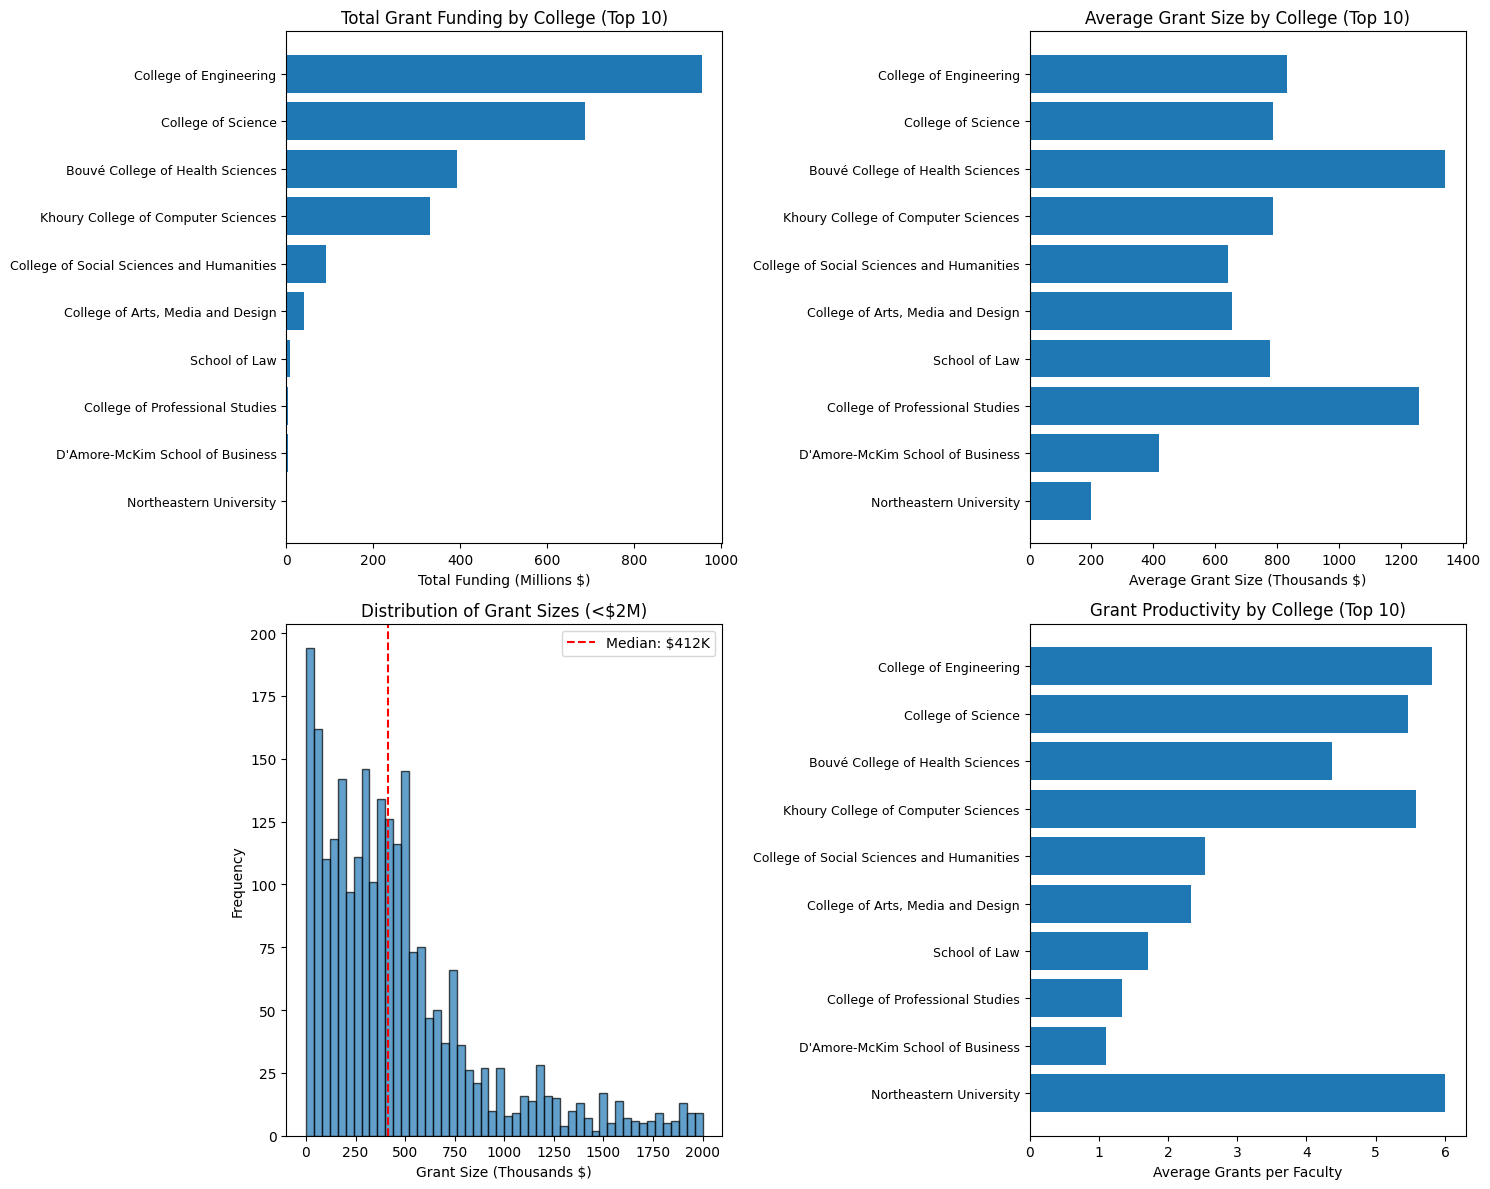


Overall grant statistics:
  Total grants: 2,676
  Total funding: $2,183,457,207
  Mean grant size: $815,941
  Median grant size: $412,028
  Min grant size: $527
  Max grant size: $38,591,094


In [57]:
# Ensure outputs directory exists
outputs_dir = PROCESSED_DIR.parent / 'outputs'
outputs_dir.mkdir(exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Total funding by college (top 10)
top_colleges = college_funding.head(10)
axes[0, 0].barh(range(len(top_colleges)), top_colleges['total_funding'] / 1e6)
axes[0, 0].set_yticks(range(len(top_colleges)))
axes[0, 0].set_yticklabels(top_colleges['superior_academic_unit'], fontsize=9)
axes[0, 0].set_xlabel('Total Funding (Millions $)')
axes[0, 0].set_title('Total Grant Funding by College (Top 10)')
axes[0, 0].invert_yaxis()

# 2. Average grant size by college
axes[0, 1].barh(range(len(top_colleges)), top_colleges['mean_grant_size'] / 1000)
axes[0, 1].set_yticks(range(len(top_colleges)))
axes[0, 1].set_yticklabels(top_colleges['superior_academic_unit'], fontsize=9)
axes[0, 1].set_xlabel('Average Grant Size (Thousands $)')
axes[0, 1].set_title('Average Grant Size by College (Top 10)')
axes[0, 1].invert_yaxis()

# 3. Grant size distribution histogram
all_grant_sizes = grants['totaldollars'] / 1000  # in thousands
axes[1, 0].hist(all_grant_sizes[all_grant_sizes < 2000], bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Grant Size (Thousands $)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Grant Sizes (<$2M)')
axes[1, 0].axvline(all_grant_sizes.median(), color='red', linestyle='--', label=f'Median: ${all_grant_sizes.median():.0f}K')
axes[1, 0].legend()

# 4. Grants per faculty by college
axes[1, 1].barh(range(len(top_colleges)), top_colleges['avg_grants_per_faculty'])
axes[1, 1].set_yticks(range(len(top_colleges)))
axes[1, 1].set_yticklabels(top_colleges['superior_academic_unit'], fontsize=9)
axes[1, 1].set_xlabel('Average Grants per Faculty')
axes[1, 1].set_title('Grant Productivity by College (Top 10)')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.savefig(outputs_dir / 'grant_size_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nOverall grant statistics:")
print(f"  Total grants: {len(grants):,}")
print(f"  Total funding: ${grants['totaldollars'].sum():,.0f}")
print(f"  Mean grant size: ${grants['totaldollars'].mean():,.0f}")
print(f"  Median grant size: ${grants['totaldollars'].median():,.0f}")
print(f"  Min grant size: ${grants['totaldollars'].min():,.0f}")
print(f"  Max grant size: ${grants['totaldollars'].max():,.0f}")

## Funding by Tenure Track Status and Grant Agency

Analysis of grant funding patterns by faculty tenure status across different funding agencies.

In [58]:
# Normalize tenure status into broader categories
def normalize_tenure_status(status):
    """Categorize tenure status into simplified buckets."""
    if pd.isna(status):
        return 'Non-Tenure Track'
    status = str(status).lower()
    if 'tenured' in status:
        return 'Tenured'
    elif 'tenure' in status and 'track' in status:
        return 'Tenure-Track (Not Tenured)'
    elif 'track' in status:
        return 'Tenure-Track (Not Tenured)'
    else:
        return 'Non-Tenure Track'

# Add normalized tenure status to faculty
faculty['tenure_category'] = faculty['tenure status'].apply(normalize_tenure_status)

# Check distribution
tenure_dist = faculty['tenure_category'].value_counts()
print("Tenure Status Distribution:")
print(tenure_dist)
print(f"\nTotal faculty: {len(faculty):,}")

Tenure Status Distribution:
tenure_category
Non-Tenure Track              1313
Tenured                        646
Tenure-Track (Not Tenured)     288
Name: count, dtype: int64

Total faculty: 2,247


In [59]:
# Merge grant data with faculty tenure status
grant_tenure = (
    grant_faculty
    .merge(faculty[['employee id', 'tenure_category', 'superior_academic_unit']], 
           left_on='clientfacultyid', right_on='employee id', how='left')
    .merge(grants[['grantid', 'totaldollars', 'agencyname', 'agencycode']], 
           on='grantid', how='left')
)

# Check for missing tenure data
missing_tenure = grant_tenure['tenure_category'].isna().sum()
print(f"Grant-faculty records with missing tenure status: {missing_tenure:,} ({missing_tenure/len(grant_tenure)*100:.1f}%)")
print(f"Total grant-faculty records: {len(grant_tenure):,}\n")

# Fill missing with 'Unknown' for analysis
grant_tenure['tenure_category'] = grant_tenure['tenure_category'].fillna('Unknown/Former Faculty')

Grant-faculty records with missing tenure status: 69 (2.2%)
Total grant-faculty records: 3,146



In [60]:
# Funding by tenure status and agency (top agencies only)
top_agencies = grants['agencycode'].value_counts().head(5).index.tolist()

tenure_agency_funding = (
    grant_tenure[grant_tenure['agencycode'].isin(top_agencies)]
    .groupby(['tenure_category', 'agencycode'], as_index=False, observed=True)
    .agg(
        total_funding=('totaldollars', 'sum'),
        mean_grant_size=('totaldollars', 'mean'),
        median_grant_size=('totaldollars', 'median'),
        n_grants=('grantid', 'nunique'),
        n_faculty=('clientfacultyid', 'nunique')
    )
    .sort_values(['agencycode', 'total_funding'], ascending=[True, False])
)

tenure_agency_funding['avg_funding_per_faculty'] = tenure_agency_funding['total_funding'] / tenure_agency_funding['n_faculty']
tenure_agency_funding['avg_grants_per_faculty'] = tenure_agency_funding['n_grants'] / tenure_agency_funding['n_faculty']

# Format for display
tenure_agency_display = tenure_agency_funding.copy()
for col in ['total_funding', 'mean_grant_size', 'median_grant_size', 'avg_funding_per_faculty']:
    tenure_agency_display[col] = tenure_agency_display[col].apply(lambda x: f'${x:,.0f}')
tenure_agency_display['avg_grants_per_faculty'] = tenure_agency_display['avg_grants_per_faculty'].apply(lambda x: f'{x:.1f}')

print(f"Funding analysis by tenure status across top {len(top_agencies)} agencies\n")
tenure_agency_display

Funding analysis by tenure status across top 5 agencies



,tenure_category,agencycode,total_funding,mean_grant_size,median_grant_size,n_grants,n_faculty,avg_funding_per_faculty,avg_grants_per_faculty
9,Tenured,NASA,"$13,605,376","$438,883","$300,000",31,13,"$1,046,567",2.4
5,Tenure-Track (Not Tenured),NASA,"$7,101,768","$2,367,256","$516,080",3,3,"$2,367,256",1.0
0,Non-Tenure Track,NASA,"$1,348,966","$89,931","$60,479",15,2,"$674,483",7.5
10,Tenured,NIH,"$754,157,064","$1,683,386","$883,979",432,123,"$6,131,358",3.5
1,Non-Tenure Track,NIH,"$63,495,931","$1,763,776","$775,853",36,13,"$4,884,302",2.8
6,Tenure-Track (Not Tenured),NIH,"$44,828,269","$711,560","$494,541",63,43,"$1,042,518",1.5
14,Unknown/Former Faculty,NIH,"$27,978,157","$1,332,293","$1,171,459",20,4,"$6,994,539",5.0
11,Tenured,NIH-SUB,"$59,474,917","$725,304","$429,358",82,23,"$2,585,866",3.6
2,Non-Tenure Track,NIH-SUB,"$12,492,584","$1,041,049","$794,396",12,3,"$4,164,195",4.0
15,Unknown/Former Faculty,NIH-SUB,"$4,247,472","$386,134","$104,423",11,3,"$1,415,824",3.7


In [61]:
# Overall tenure status funding analysis (all agencies)
tenure_overall = (
    grant_tenure
    .groupby('tenure_category', as_index=False, observed=True)
    .agg(
        total_funding=('totaldollars', 'sum'),
        mean_grant_size=('totaldollars', 'mean'),
        median_grant_size=('totaldollars', 'median'),
        n_grants=('grantid', 'nunique'),
        n_faculty=('clientfacultyid', 'nunique')
    )
    .sort_values('total_funding', ascending=False)
)

tenure_overall['avg_funding_per_faculty'] = tenure_overall['total_funding'] / tenure_overall['n_faculty']
tenure_overall['avg_grants_per_faculty'] = tenure_overall['n_grants'] / tenure_overall['n_faculty']
tenure_overall['pct_of_total_funding'] = (tenure_overall['total_funding'] / tenure_overall['total_funding'].sum() * 100)

# Format for display
tenure_overall_display = tenure_overall.copy()
for col in ['total_funding', 'mean_grant_size', 'median_grant_size', 'avg_funding_per_faculty']:
    tenure_overall_display[col] = tenure_overall_display[col].apply(lambda x: f'${x:,.0f}')
tenure_overall_display['avg_grants_per_faculty'] = tenure_overall_display['avg_grants_per_faculty'].apply(lambda x: f'{x:.1f}')
tenure_overall_display['pct_of_total_funding'] = tenure_overall_display['pct_of_total_funding'].apply(lambda x: f'{x:.1f}%')

print("Overall funding by tenure status (all agencies)\n")
tenure_overall_display

Overall funding by tenure status (all agencies)



,tenure_category,total_funding,mean_grant_size,median_grant_size,n_grants,n_faculty,avg_funding_per_faculty,avg_grants_per_faculty,pct_of_total_funding
2,Tenured,"$2,271,289,439","$869,227","$429,134",2246,396,"$5,735,579",5.7,84.3%
0,Non-Tenure Track,"$211,426,793","$952,373","$401,202",210,48,"$4,404,725",4.4,7.8%
1,Tenure-Track (Not Tenured),"$151,140,639","$624,548","$493,565",234,113,"$1,337,528",2.1,5.6%
3,Unknown/Former Faculty,"$61,145,598","$886,168","$545,000",68,13,"$4,703,508",5.2,2.3%


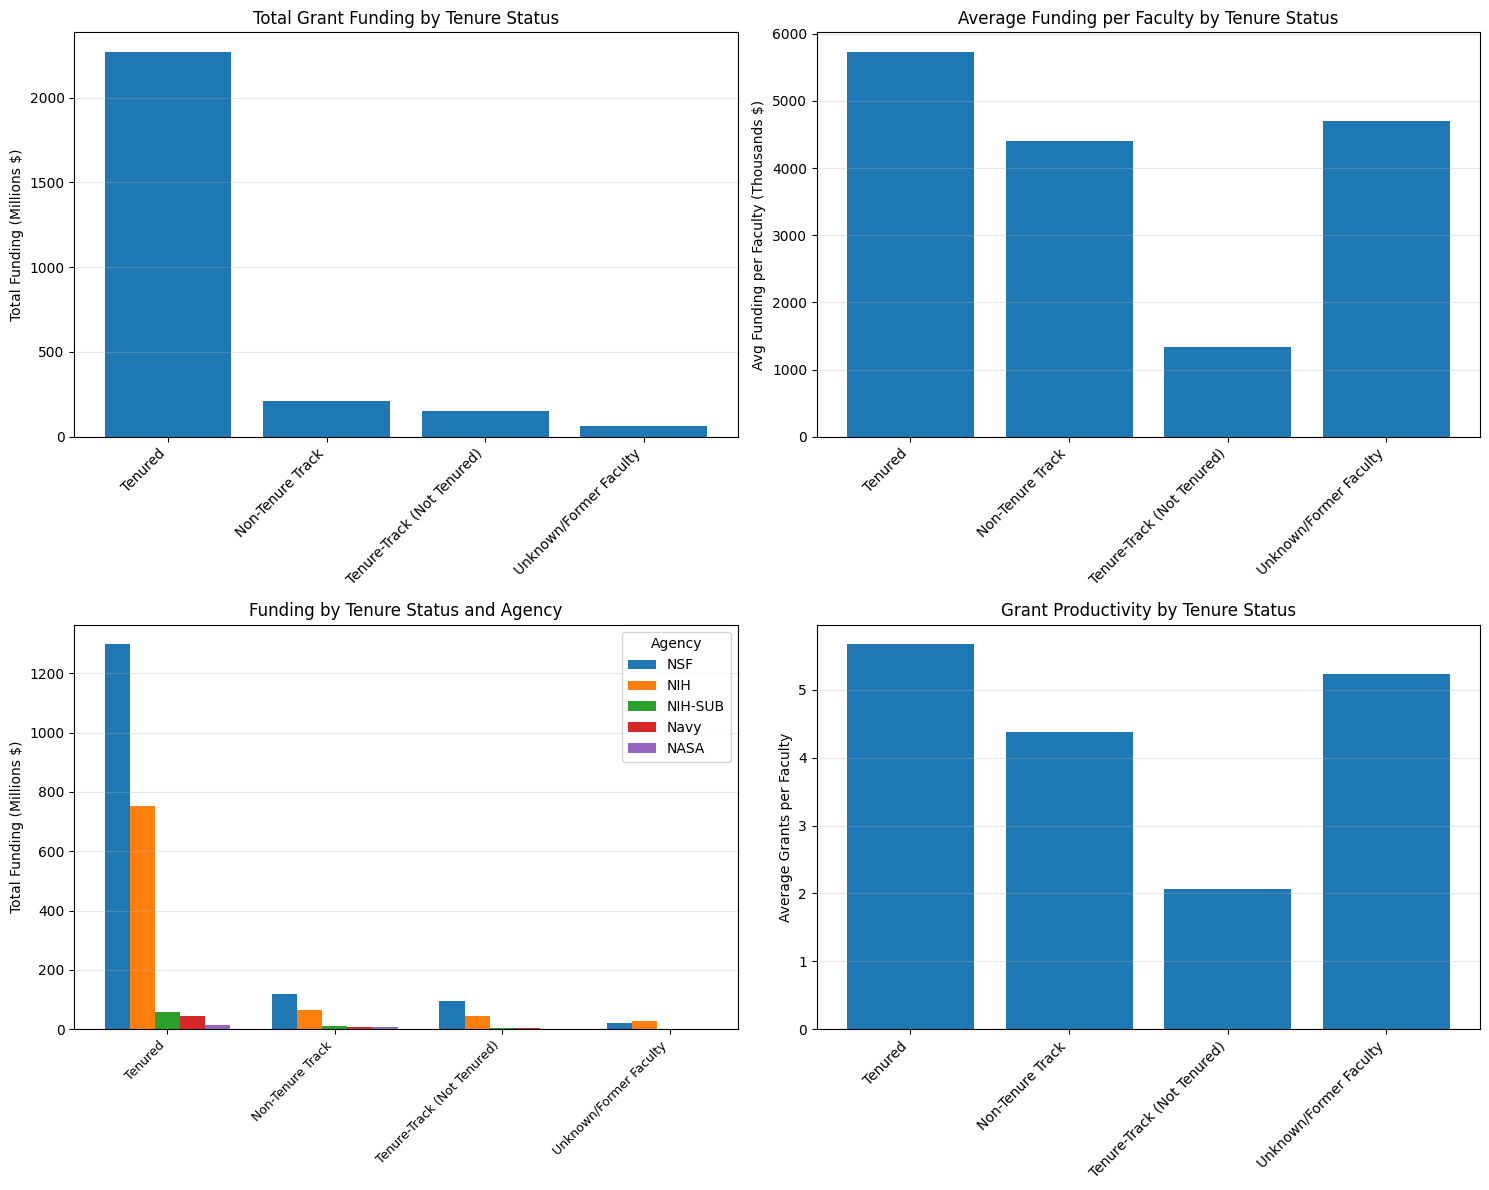

In [62]:
# Visualize tenure status funding patterns
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Total funding by tenure status
axes[0, 0].bar(range(len(tenure_overall)), tenure_overall['total_funding'] / 1e6)
axes[0, 0].set_xticks(range(len(tenure_overall)))
axes[0, 0].set_xticklabels(tenure_overall['tenure_category'], rotation=45, ha='right')
axes[0, 0].set_ylabel('Total Funding (Millions $)')
axes[0, 0].set_title('Total Grant Funding by Tenure Status')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Average funding per faculty by tenure status
axes[0, 1].bar(range(len(tenure_overall)), tenure_overall['avg_funding_per_faculty'] / 1000)
axes[0, 1].set_xticks(range(len(tenure_overall)))
axes[0, 1].set_xticklabels(tenure_overall['tenure_category'], rotation=45, ha='right')
axes[0, 1].set_ylabel('Avg Funding per Faculty (Thousands $)')
axes[0, 1].set_title('Average Funding per Faculty by Tenure Status')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Funding by tenure and agency (grouped bar)
for i, agency in enumerate(top_agencies):
    agency_data = tenure_agency_funding[tenure_agency_funding['agencycode'] == agency]
    x_pos = np.arange(len(agency_data)) + i * 0.15
    axes[1, 0].bar(x_pos, agency_data['total_funding'] / 1e6, width=0.15, label=agency)

axes[1, 0].set_xticks(np.arange(len(tenure_overall)) + 0.3)
axes[1, 0].set_xticklabels(tenure_overall['tenure_category'], rotation=45, ha='right', fontsize=9)
axes[1, 0].set_ylabel('Total Funding (Millions $)')
axes[1, 0].set_title('Funding by Tenure Status and Agency')
axes[1, 0].legend(title='Agency')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Grant productivity by tenure status
axes[1, 1].bar(range(len(tenure_overall)), tenure_overall['avg_grants_per_faculty'])
axes[1, 1].set_xticks(range(len(tenure_overall)))
axes[1, 1].set_xticklabels(tenure_overall['tenure_category'], rotation=45, ha='right')
axes[1, 1].set_ylabel('Average Grants per Faculty')
axes[1, 1].set_title('Grant Productivity by Tenure Status')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(PROCESSED_DIR.parent / 'outputs' / 'tenure_funding_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

### Calculate number of grants that have abstracts available vs not available (ri_matches_grants_2026 vs grans_with_abstracts)

In [63]:
total_grants = grants['grantid'].nunique()
matched = grants['grantid'].isin(grant_text['sourceactivityid'].unique())
n_with_abstract = matched.sum()
n_without = total_grants - n_with_abstract

print(f"Total grants (ri_matches): {total_grants:,}")
print(f" With abstract : {n_with_abstract:,} ({n_with_abstract/total_grants*100:.1f}%)")
print(f" Without abstract : {n_without:,} ({n_without/total_grants*100:.1f}%)\n")


grant_abstracts = grant_text[['id', 'title', 'abstract']].drop_duplicates(subset=['id'])
total_grants = grant_abstracts['id'].nunique()
has_abstract = grant_abstracts['abstract'] != '' # fillna('') in pipeline, so notna() is always True
abstract_counts = has_abstract.value_counts().reindex([True, False], fill_value=0)

print("Abstract text availability within grant_text:")
print(f" Has text : {abstract_counts[True]:,} ({abstract_counts[True]/total_grants*100:.1f}%)")
print(f" Empty : {abstract_counts[False]:,} ({abstract_counts[False]/total_grants*100:.1f}%)")

Total grants (ri_matches): 2,676
 With abstract : 2,410 (90.1%)
 Without abstract : 266 (9.9%)

Abstract text availability within grant_text:
 Has text : 2,873 (35.6%)
 Empty : 5,202 (64.4%)



KEY FINDING: Grants with at least one non-empty abstract
Total unique grants            : 2,676
With ≥1 non-empty abstract     : 1,928 (72.0%)
No non-empty abstract          : 748 (28.0%)



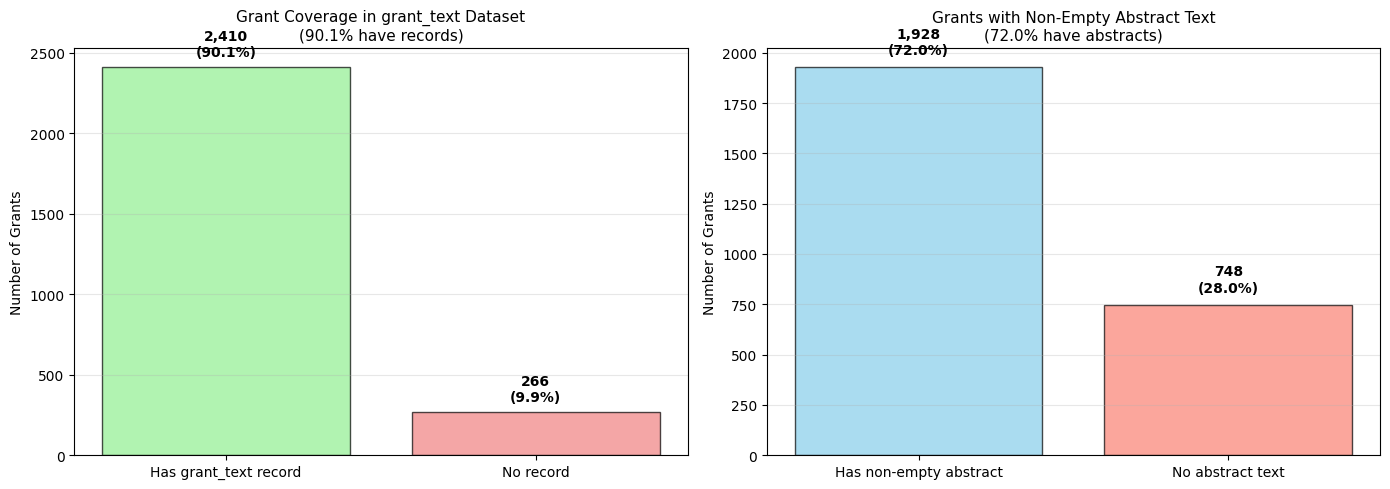

In [64]:
# BUT: What percentage of the 2,676 grants have at least one non-empty abstract?
# Get grant_text entries with non-empty abstracts
grants_with_text = grant_text[grant_text['abstract'] != '']['sourceactivityid'].unique()

# Total unique grants in grants dataset
total_unique_grants = grants['grantid'].nunique()

# Grants that have at least one non-empty abstract
n_grants_with_abstract = grants['grantid'].isin(grants_with_text).sum()
n_grants_without = total_unique_grants - n_grants_with_abstract

print(f"\n{'='*60}")
print(f"KEY FINDING: Grants with at least one non-empty abstract")
print(f"{'='*60}")
print(f"Total unique grants            : {total_unique_grants:,}")
print(f"With ≥1 non-empty abstract     : {n_grants_with_abstract:,} ({n_grants_with_abstract/total_unique_grants*100:.1f}%)")
print(f"No non-empty abstract          : {n_grants_without:,} ({n_grants_without/total_unique_grants*100:.1f}%)")
print(f"{'='*60}\n")

# Visualize this more accurate metric
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Grant coverage in grant_text (90.1% have records)
coverage_data = [n_with_abstract, n_without]
colors1 = ['lightgreen', 'lightcoral']
ax1.bar([0, 1], coverage_data, color=colors1, edgecolor='black', alpha=0.7)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Has grant_text record', 'No record'], rotation=0)
ax1.set_ylabel('Number of Grants')
ax1.set_title(f'Grant Coverage in grant_text Dataset\n({n_with_abstract/total_unique_grants*100:.1f}% have records)', fontsize=11)
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(coverage_data):
    ax1.text(i, v + 50, f'{v:,}\n({v/total_unique_grants*100:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Right: Actual abstract text availability (only 45.9% have non-empty text)
abstract_data = [n_grants_with_abstract, n_grants_without]
colors2 = ['skyblue', 'salmon']
ax2.bar([0, 1], abstract_data, color=colors2, edgecolor='black', alpha=0.7)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Has non-empty abstract', 'No abstract text'], rotation=0)
ax2.set_ylabel('Number of Grants')
ax2.set_title(f'Grants with Non-Empty Abstract Text\n({n_grants_with_abstract/total_unique_grants*100:.1f}% have abstracts)', fontsize=11)
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(abstract_data):
    ax2.text(i, v + 50, f'{v:,}\n({v/total_unique_grants*100:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()